# Sivers: azimuthal-acceptance comparison

The SoLID 3He (neutron) Sivers fit across **five** pseudodata configurations, all
generated in this repo and all fitted at 500 replicas, against the world-data fit
as the reference. The Sivers counterpart of `plot-transversity_phicompare.ipynb`;
the physics machinery (`f1tcalcorr`, `tmd.f1Tperp1`, the
$xf_{1T}^{\perp(1)}$ observable) is unchanged.

| key | run directory | acceptance | binning | bins |
|---|---|---|---|---|
| `world` | `../data_world` | existing world data — **the reference** | — | 234 rows |
| `sbs` | `../data_world` | SBS projection — a second external reference, **stat-only panel** | — | 455 rows |
| `phifull` | `data_phifull` | full 2π (100%) | own | 1660 |
| `phi4seg_fullbin` | `data_phi4seg24deg_phifullbin` | 4 × 24° (26.7% nominal), both arms | **reused from `phifull`** | 1660 |
| `phi4seg` | `data_phi4seg24deg` | 4 × 24°, both arms | own | 169 |
| `phi4segFA_fullbin` | `data_phi4seg24degFA_phifullbin` | 4 × 24°, **forward angle only** (large-angle e⁻ keeps full 2π) | **reused from `phifull`** | 1660 |
| `phi4segFA` | `data_phi4seg24degFA` | 4 × 24°, forward angle only | own | 239 |

The `*_fullbin` runs share `phifull`'s bins, so they pair 1:1 with it and with
each other — those are the ones to compare. The own-bins runs re-binned under
their own acceptance, trading fewer bins for more events in each, which makes
them look better at equal acceptance for reasons of bin width rather than physics.

**The nominal coverage is not the event cost.** The cut applies to the electron
and the hadron alike, so a coincidence survives roughly 26.7² ≈ 7.1%; measured,
the median surviving yield is 4.8%. See `README.md` in this directory.

*(Rewritten 2026-08-31: the previous version read `output*` directories and
`tmdlib.tmd` from the upstream tree, and covered 6×24° and 4×12°FA
configurations that do not exist here.)*

**SBS is a reference, not a SoLID configuration.** It is an external projection with no systematics model of its own, so there is a single SBS fit rather than a stat/syst pair, and it is drawn in the **stat-only panel only** — absent from every stat+syst panel and table rather than repeated there unchanged. Fitted at 500 replicas like everything else, so its 3.2% replica-sampling noise is the same as the rest.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))   # tmd.py lives at the repo root
import tmd

# Its own gallery: pointed at 'gallery' this would overwrite the tracked
# phi-cut figures with a different comparison.
GALLERY = 'gallery_sbsenhanced3he'
os.makedirs(GALLERY, exist_ok=True)

Q2  = 2.4
tol = 1.5    # Sivers value (the transversity notebook uses 7.04); it cancels in
             # every error RATIO below, so the comparisons do not depend on it

LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/CJ15lo/CJ15lo_0000.dat
CJ15lo PDF set, member #0, version 2; LHAPDF ID = 12300
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0211.dat
DSSFFlo PDF set, member #211, version 1; LHAPDF ID = 90211
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0321.dat
DSSFFlo PDF set, member #321, version 1; LHAPDF ID = 90321
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/NNPDFpol11_100/NNPDFpol11_100_0000.dat
NNPDFpol11_100 PDF set, member #0, version 1; LHAPDF ID = 251000


## Load fit results

Each file is the raw per-replica parameter table (50 rows x `Nu,au,bu,cu,Nd,ad,bd,cd,Nub,Ndb,kt2,chi2`).

In [2]:
# SoLID 3He COMBINED WITH THE SBS PROJECTION (fit opt 'sbs+enhanced3he').
#
# Statistical only, and there is no stat+syst counterpart -- deliberately.
# The SBS projection carries no systematics model (prepare.py's prepare_sbs
# builds no fn, systabs or systrel), so 'sbs+enhanced3hesyst' does not exist:
# both fit scripts refuse it by name rather than let a stat-only SBS be
# combined with SoLID's stat+syst and silently over-weight SBS. Every
# stat+syst panel below is therefore switched off rather than left to render
# the world reference alone.
STAT = 'out-sbsenhanced3he_sivers.dat'

# The 4x-counts twin, from the fit scripts' -c 4 flag. Only the SoLID half of the
# combined set is scaled: --counts never touches the SBS projection, because more
# SoLID beam time does not give SBS more events. So these curves are SBS at its own
# fixed luminosity plus SoLID at four times its nominal counts -- which is exactly
# the question, how much a phi-cut SoLID needs to make the pair competitive.
STAT_X4 = STAT.replace('.dat', '_x4counts.dat')

# REF is the denominator of every error ratio below.
REF = 'world'

# Three curves and the world reference, matching plot-sivers_phicompare.ipynb:
# the full-2pi run at nominal luminosity against the two phi-cut runs at 4x. There
# is no separate SBS-only curve here by design -- every curve in this notebook
# already contains SBS, so an SBS-alone entry would be a different quantity sharing
# an axis. The 1x twins of the two phi-cut runs live in the phicompare notebook's
# earlier revisions and in plot-sivers_phicompare_x4counts.ipynb.
RUNS = {
    'world':             {'dir': '../data_world',
                          # the world fit has no stat/syst variants -- the same
                          # fit is the reference in both panels
                          'files': {'': 'out-world_sivers.dat'},
                          'label': r'$\rm world~data$',
                          'color': 'gray'},
    'phifull':           {'dir': 'data_phifull',
                          'files': {'': STAT},
                          'label': r'$\rm SBS+SoLID~2\pi$',
                          'color': 'black'},
    'phi4seg_fullbin_x4': {'dir': 'data_phi4seg24deg_phifullbin',
                          'files': {'': STAT_X4},
                          'label': r'$\rm SBS+4\times24^\circ~(2\pi~bins,~4\times~counts)$',
                          'color': 'green'},
    # same 4x24 deg acceptance as above; 169 bins of its own rather than phifull's
    # 1660, so it shares no bin with the others -- compare the shape, never a value
    # at a given bin index.
    'phi4seg_x4':        {'dir': 'data_phi4seg24deg',
                          'files': {'': STAT_X4},
                          'label': r'$\rm SBS+4\times24^\circ~(own~bins,~4\times~counts)$',
                          'color': 'darkorange'},
}
# Every loop below iterates runs_for(suffix), so each run appears in exactly the
# panels it has a fit for. With VARIANTS = [''] that is the stat panel only.
def runs_for(suffix):
    return [(run, cfg) for run, cfg in RUNS.items() if suffix in cfg['files']]

VARIANTS = ['']   # no stat+syst variant exists for this opt

par = {}
for run, cfg in RUNS.items():
    for suf in VARIANTS:
        if suf not in cfg['files']:
            print(f'{run+suf:24s} {"-- no fit; absent from this panel":52s}')
            continue
        path = os.path.join(cfg['dir'], cfg['files'][suf])
        par[run + suf] = pd.read_csv(path, sep=r'\s+', index_col=False)
        print(f'{run+suf:24s} {path:60s} {len(par[run+suf])} replicas')


world                    ../data_world/out-world_sivers.dat                           500 replicas
phifull                  data_phifull/out-sbsenhanced3he_sivers.dat                   500 replicas
phi4seg_fullbin_x4       data_phi4seg24deg_phifullbin/out-sbsenhanced3he_sivers_x4counts.dat 500 replicas
phi4seg_x4               data_phi4seg24deg/out-sbsenhanced3he_sivers_x4counts.dat     500 replicas


### Fitted parameters, run by run

In [3]:
rows = []
for key, p in par.items():
    r = {'run': key}
    for c in p.columns:
        r[c] = f'{p[c].mean():.4f} +- {p[c].std():.4f}'
    rows.append(r)
pd.set_option('display.width', 250)
partable = pd.DataFrame(rows).set_index('run')
partable[['Nu', 'au', 'bu', 'Nd', 'ad', 'bd', 'kt2', 'chi2']]

,Nu,au,bu,Nd,ad,bd,kt2,chi2
run,,,,,,,,
world,-0.0387 +- 0.0019,0.6663 +- 0.1130,4.1564 +- 1.0440,0.0576 +- 0.0154,0.4381 +- 0.2504,3.8314 +- 3.1709,0.1592 +- 0.0300,226.1234 +- 20.8210
phifull,-0.0375 +- 0.0061,0.6325 +- 0.0457,4.1345 +- 0.7774,0.0500 +- 0.0046,0.3758 +- 0.0432,3.3100 +- 0.5135,0.1600 +- 0.0016,2104.1759 +- 64.4775
phi4seg_fullbin_x4,-0.0364 +- 0.0077,0.6142 +- 0.0742,4.2089 +- 0.9032,0.0493 +- 0.0058,0.3633 +- 0.0605,3.3576 +- 0.6358,0.1602 +- 0.0033,2104.7534 +- 64.5711
phi4seg_x4,-0.0359 +- 0.0078,0.6113 +- 0.0660,4.2508 +- 0.9233,0.0496 +- 0.0057,0.3669 +- 0.0563,3.3237 +- 0.6561,0.1602 +- 0.0045,617.4845 +- 36.4799


## Calculate $xf_{1T}^{\perp(1)}(x)$

Follows `f1tcalc()` in `plot-sivers.ipynb`: for each $x$, evaluate
`tmd.f1Tperp1` once per replica using that replica's own parameters, take the
valence combination $q - \bar q$, then central value = mean, error = `tol` × std.

(`Nub`/`Ndb` are fixed to 0 in `fitsim`, so the $\bar q$ terms vanish — the
subtraction is kept for fidelity with the reference notebook.)

In [4]:
def f1tcalcorr(pset, Q2, tol):
    rows = []
    X = np.linspace(1e-3, 1, 200)
    pset = pset.reset_index(drop=True)
    for x in X:
        # errors only -- central values are untouched. Identically 1 for x <= 0.4,
        # exp(-6.8*(x-0.4)^2) above: x0.76 at x=0.6, x0.34 at x=0.8, x0.09 at x=1.
        corr = np.exp(-1.7 * (np.abs(x - 0.4) + x - 0.4)**2)
        xu, xd = [], []
        for i in range(len(pset)):
            f1t = tmd.f1Tperp1(x, Q2, 'proton', pset.loc[i])
            xu.append(x * (f1t[2] - f1t[-2]))
            xd.append(x * (f1t[1] - f1t[-1]))
        rows.append({'x': x,
                     'xu': np.mean(xu), 'Exu': tol * np.std(xu) * corr,
                     'xd': np.mean(xd), 'Exd': tol * np.std(xd) * corr})
    return pd.DataFrame(rows)

In [5]:
%%time
f1t = {}
for key in par:
    f1t[key] = f1tcalcorr(par[key], Q2, tol)
    print('done', key)

done world


done phifull


done phi4seg_fullbin_x4


done phi4seg_x4
CPU times: user 35 s, sys: 7.28 ms, total: 35.1 s
Wall time: 35.2 s


## $xf_{1T}^{\perp(1)}(x)$ bands, three runs overlaid

Top panel: $u$ (solid) and $d$ (dashed) Sivers first-moment bands. Bottom panel:
each φ-cut run's uncertainty relative to the full-2π baseline — above 1 means
the φ cut degrades the projection. `tol` cancels in the bottom panel.

In [6]:
def band_plot(suffix, fname, title):
    fig = plt.figure(figsize=(6.5, 10))

    ax = fig.add_subplot(2, 1, 1)
    for run, cfg in runs_for(suffix):
        d = f1t[run + suffix]
        ax.fill_between(d['x'], d['xu'] - d['Exu'], d['xu'] + d['Exu'],
                        color=cfg['color'], alpha=0.30, linewidth=0)
        ax.fill_between(d['x'], d['xd'] - d['Exd'], d['xd'] + d['Exd'],
                        color=cfg['color'], alpha=0.30, linewidth=0)
        ax.plot(d['x'], d['xu'], color=cfg['color'], linewidth=1.2, label=cfg['label'])
        ax.plot(d['x'], d['xd'], color=cfg['color'], linewidth=1.2, linestyle='--')
    ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_ylabel(r'$xf_{1T}^{\perp(1)}(x)$', size=25)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.042, 0.05)
    ax.set_xticklabels([])
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.text(0.5, 0.96, title, horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=17)
    ax.text(0.03, 0.90, r'$Q^2 = $' + f'{Q2:g}' + r'$~{\rm GeV}^2$',
            transform=ax.transAxes, fontsize=13)
    # u and d labelled ON the curves, placed by the SIGN of each lobe so the reader
    # never has to work out which is which. The world fit is used for the position
    # because it is present in every panel.
    dref = f1t[REF + suffix]
    j = int(np.argmin(np.abs(dref['x'].values - 0.10)))
    lo, hi = ax.get_ylim()
    pad = 0.045 * (hi - lo)
    for q, lab in (('xu', 'u'), ('xd', 'd')):
        v = dref[q].values[j]
        ax.text(0.10, v + (pad if v >= 0 else -pad), rf'${lab}$', fontsize=19,
                ha='center', va='bottom' if v >= 0 else 'top', color='black')
    ax.legend(loc='lower right', frameon=False, fontsize=11)

    ax = fig.add_subplot(2, 1, 2)
    ref = f1t[REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = f1t[run + suffix]
        ax.plot(d['x'], ref['Exu'] / d['Exu'], color=cfg['color'], alpha=0.8,
                linestyle='-',  linewidth=3, label=cfg['label'] + r'$~u$')
        ax.plot(d['x'], ref['Exd'] / d['Exd'], color=cfg['color'], alpha=0.8,
                linestyle='--', linewidth=3, label=cfg['label'] + r'$~d$')
    ax.axhline(y=1, linestyle='-', color='black', alpha=0.6, linewidth=1)
    for y in (10, 20, 30, 40):
        ax.axhline(y=y, linestyle=':', color='black', alpha=0.5, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_xlabel(r'$x$', size=25)
    ax.set_ylabel(r'$\rm Error^{world}/Error$', size=20)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 60)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.legend(loc='upper right', frameon=False, fontsize=9, ncol=2)

    fig.tight_layout()
    fig.savefig(f'{GALLERY}/{fname}')
    return fig

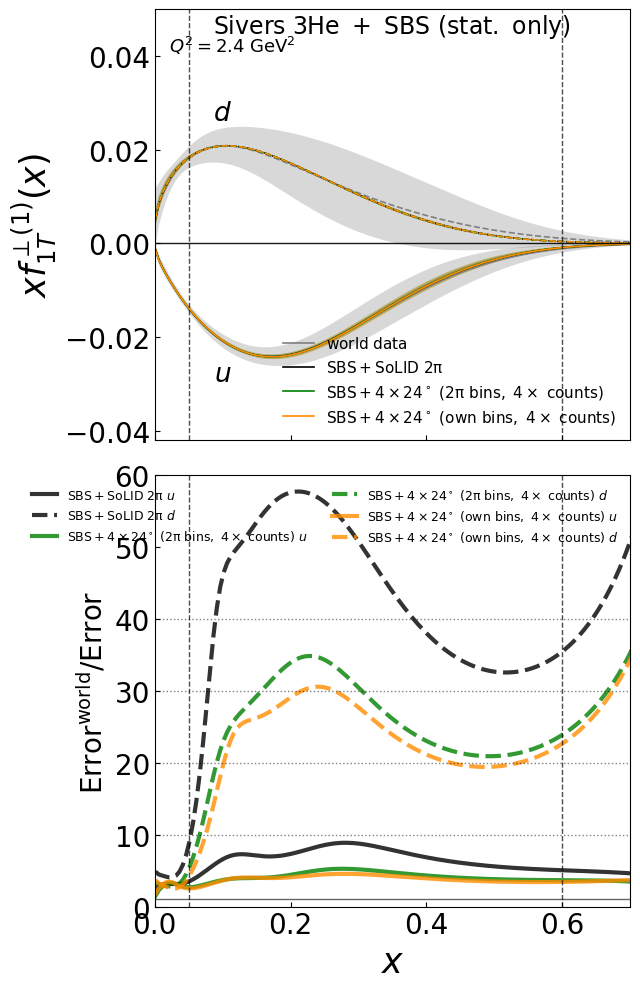

In [7]:
band_plot('', 'sivers-phicompare.pdf',
          r'$\rm Sivers~3He~+~SBS~(stat.~only)$');

In [8]:
# stat+syst band figure omitted: 'sbs+enhanced3he' has no syst
# variant, so this panel would show the world reference alone.


## Uncertainty ratio at representative $x$

Same information as the bottom panels, tabulated across the SoLID coverage.

In [9]:
XPTS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

rows = []
for suffix, sname in [('', 'stat')]:
    ref = f1t[REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = f1t[run + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d['x'].values - x)))
                r[f'x={x}'] = round(ref[q].values[j] / d[q].values[j], 2)
            rows.append(r)
print('Error^world / Error  (larger = SoLID better; 20 means 20x more precise)')
pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])

Error^world / Error  (larger = SoLID better; 20 means 20x more precise)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  x=0.5  x=0.6
variant run                quark                                                  
stat    phifull            u        3.54   6.66   7.36   8.75   6.90   5.61   5.06
                           d        9.11  46.49  57.67  50.52  38.29  32.73  35.36
        phi4seg_fullbin_x4 u        2.69   3.72   4.45   5.17   4.35   3.82   3.67
                           d        5.54  23.14  34.06  30.27  23.17  20.93  23.80
        phi4seg_x4         u        2.53   3.67   4.09   4.52   3.93   3.49   3.43
                           d        4.35  20.01  29.22  27.55  21.27  19.47  22.57

## Parameter-level summary

The Sivers fit has no tensor-charge analogue of $g_T$, so the compact summary is
the replica spread of the fitted parameters themselves. `kt2` is the one to
watch: it sets the transverse-momentum width, which is what an azimuthal
acceptance cut degrades most directly.

**Do not read the "vs world" parameter column as a precision comparison.**
`fitworld()` and `fitsim()` fix *different* parameters: the world fit floats 7
(`fix=[F,F,F,T,F,F,F,T,T,T,F]` — `cu`, `cd`, `Nub`, `Ndb` held), while the SoLID
fits float 9 (only `Nub`, `Ndb` held). Letting `cu`/`cd` float gives the SoLID
replicas extra freedom that inflates individual parameter spreads, which is why
`Nu` comes out with a *larger* std than world's despite SoLID being far more
precise on the actual observable. The band ratios above (which marginalise over
the whole parameter set) are the meaningful comparison against world; the
run-to-run column below, which compares like-configured `fitsim` outputs to each
other, is the meaningful one for the φ-cut effect.

In [10]:
COLS = ['Nu', 'au', 'bu', 'Nd', 'ad', 'bd', 'kt2']

for suffix, sname in [('', 'stat')]:
    print(f'--- {sname}: std(world)/std, larger = better '
          f'(NOT a precision comparison -- different params fixed, see above) ---')
    ref = par[REF + suffix]
    for run, cfg in runs_for(suffix):
        cells = [f'{c}={ref[c].std()/par[run+suffix][c].std():.2f}' for c in COLS]
        print(f'  {run:18s} ' + '  '.join(cells))
    print()

for suffix, sname in [('', 'stat')]:
    print(f'--- {sname}: replica-std ratio to SoLID full-2pi '
          f'(like-for-like -- this is the phi-cut effect) ---')
    ref = par['phifull' + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        cells = [f'{c}={par[run+suffix][c].std()/ref[c].std():.3f}' for c in COLS]
        print(f'  {run:18s} ' + '  '.join(cells))
    print()

print('--- systematics penalty: std(stat+syst) / std(stat) ---')
for run, cfg in runs_for('syst'):
    if run == REF:
        continue          # world has no syst variant; SBS is already excluded
    cells = [f'{c}={par[run+"syst"][c].std()/par[run][c].std():.2f}' for c in COLS]
    print(f'  {run:18s} ' + '  '.join(cells))
print()
print('Ratios marginally below 1.0 are 500-replica sampling noise (3.2%), not a')
print('real reduction -- adding systematics cannot shrink an error. Use them as')
print('the scale for how much of the near-1.0 numbers above is meaningful.')

--- stat: std(world)/std, larger = better (NOT a precision comparison -- different params fixed, see above) ---
  world              Nu=1.00  au=1.00  bu=1.00  Nd=1.00  ad=1.00  bd=1.00  kt2=1.00
  phifull            Nu=0.31  au=2.48  bu=1.34  Nd=3.32  ad=5.80  bd=6.18  kt2=18.87
  phi4seg_fullbin_x4 Nu=0.24  au=1.52  bu=1.16  Nd=2.68  ad=4.14  bd=4.99  kt2=9.09
  phi4seg_x4         Nu=0.24  au=1.71  bu=1.13  Nd=2.72  ad=4.44  bd=4.83  kt2=6.64

--- stat: replica-std ratio to SoLID full-2pi (like-for-like -- this is the phi-cut effect) ---
  phifull            Nu=1.000  au=1.000  bu=1.000  Nd=1.000  ad=1.000  bd=1.000  kt2=1.000
  phi4seg_fullbin_x4 Nu=1.267  au=1.626  bu=1.162  Nd=1.240  ad=1.403  bd=1.238  kt2=2.075
  phi4seg_x4         Nu=1.275  au=1.447  bu=1.188  Nd=1.221  ad=1.306  bd=1.278  kt2=2.843

--- systematics penalty: std(stat+syst) / std(stat) ---

Ratios marginally below 1.0 are 500-replica sampling noise (3.2%), not a
real reduction -- adding systematics cannot shrink